In [1]:
import sys
sys.path.insert(0,'../scripts')
from pycap_for_PESTPP_MOU import postprocess_MOU, plot_pareto, prep_for_viz, create_viz_app, plot_pareto_with_scenarios
from pathlib import Path
from ipywidgets import interact, fixed
import yaml



# Read in one of the configuration files and postprocess it. 
### The `config_file` should be your `secnario_name` + `".yml"` as assigned in the `05_MOU_setup_run.ipynb` notebook. 

In [2]:
config_file = 'ant_group_run.yml'

with open(Path('./configurations') / config_file,'r') as ifp:
    inpars = yaml.safe_load(ifp)
inpars

{'depletion_potential_threshold': 0.2,
 'objectives': 'depletion_q',
 'pump_lbound_fraction': 0.6,
 'pump_ubound_fraction': 1.0,
 'ref_q': 8.6,
 'run_path': '../pycap_runs/pycap_pest/run_ant_group_run',
 'scenario_name': 'ant_group_run'}

### Below, the `config_file` is processed, beginning the postprocessing

In [3]:
run_path = Path(inpars['run_path'])
run_name = inpars['scenario_name']
pareto_df = postprocess_MOU(run_name, run_path)

In [4]:
pareto_df

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
0,0,10,4.89771,4589.24,1,1.000000e+30,0.008043,0.008043,1,-999
1,0,1,4.43955,3931.63,1,1.000000e+30,0.005179,0.005179,1,-999
2,0,12,4.82867,4544.43,1,3.410520e-01,0.012575,0.012575,1,-999
3,0,36,4.69714,4466.91,1,3.165240e-01,0.008043,0.008043,1,-999
4,0,30,4.63622,4281.51,1,2.119700e-01,0.016071,0.016071,1,-999
...,...,...,...,...,...,...,...,...,...,...
4805,50,gen=50_member=1871_pso,3.68535,3261.43,1,2.558940e-02,0.007847,0.007847,1,-999
4808,50,gen=50_member=1882_pso,4.18190,3882.45,1,7.554660e-03,0.039510,0.039510,1,-999
4809,50,gen=50_member=1895_pso,4.33766,4019.82,1,4.736710e-03,1.032260,1.032260,1,-999
4810,50,gen=50_member=1869_pso,3.66894,3235.04,1,2.896770e-02,2.007040,2.007040,1,-999


### Next the evolution of the pareto frontier is plotted, over MOU iterations. Check out how the algorithm converges on a well-defined pareto tradeoff frontier

In [ ]:
interact(plot_pareto,  currgen=(0,50,1), pareto_df=fixed(pareto_df));

interactive(children=(IntSlider(value=25, description='currgen', max=50), Output()), _dom_classes=('widget-int…

### Where do your scenarios line up? You can provide a list of scenarios that you ran in notebook #3 in the following function to plot a red "x" where each scenario plots up

no scenarios provided


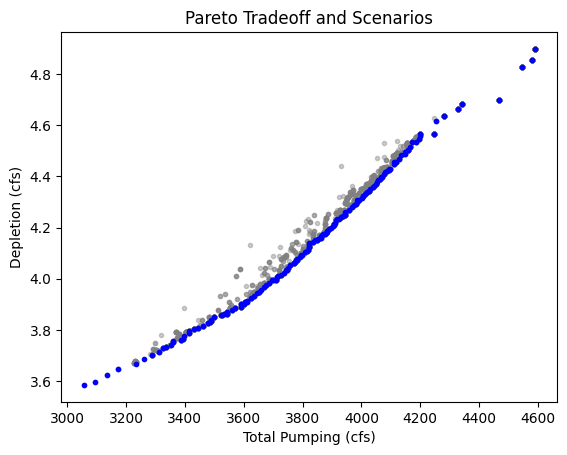

In [8]:
plot_pareto_with_scenarios(pareto_df)

### Finally, there is an interactive plot with the pareto frontier on the left and a map of corresponding "optimal" pumping rates on the right. 

### Note - if you get an error about ports being in conflict, change the `port=4242` argument to a different number than `4242`

In [9]:
dollars=False
if 'dollar' in inpars['objectives']:
    dollars = True
pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=dollars)
app = create_viz_app(pareto_df_final, dv_df)
app.run(port=4242)

error parsing metadata from 'obsnme', continuing


### check out `pareto_df_final` and `dv_df`. What's in these datasets? What further analysis can you perform with this information?

In [10]:
dv_df.sample(10)

,gen=49_member=1851_pso,10,12,36,gen=47_member=1780_pso,8,20,gen=48_member=1816_pso,gen=47_member=1750_pso,28,...,gen=42_member=1588_pso,gen=20_member=736_pso,gen=50_member=1874_pso,gen=50_member=1879_pso,gen=50_member=1871_pso,gen=50_member=1882_pso,gen=50_member=1895_pso,gen=50_member=1869_pso,gen=50_member=1886_pso,geometry
well_69288,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.35788 44.48537)
well_23846,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.46118 44.52898)
well_73761,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.42726 44.48318)
well_73440,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.4059 44.4189)
well_71044,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.49693 44.4836)
well_72437,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.38838 44.44745)
well_67895,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.4622 44.39723)
well_23770,0.924261,1.02259,1.175201,1.130986,1.0,1.100731,0.97272,1.0,1.0,0.895132,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.50337 44.47951)
well_24130,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.5179 44.40333)
well_23928,1.000000,1.00000,1.000000,1.000000,1.0,1.000000,1.00000,1.0,1.0,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,POINT (-89.44087 44.4437)


In [ ]:
pareto_df_final

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
4642,50,gen=49_member=1851_pso,3.58536,3056.42,1,1.000000e+30,0.003267,0.003267,1,-999
4643,50,10,4.89771,4589.24,1,1.000000e+30,0.002470,0.002470,1,-999
4644,50,12,4.82867,4544.43,1,1.190650e-01,0.002777,0.002777,1,-999
4645,50,36,4.69714,4466.91,1,1.105020e-01,0.003539,0.003539,1,-999
4646,50,gen=47_member=1780_pso,4.61667,4254.06,1,5.471030e-02,0.010248,0.010248,1,-999
...,...,...,...,...,...,...,...,...,...,...
4805,50,gen=50_member=1871_pso,3.68535,3261.43,1,2.558940e-02,0.007847,0.007847,1,-999
4808,50,gen=50_member=1882_pso,4.18190,3882.45,1,7.554660e-03,0.039510,0.039510,1,-999
4809,50,gen=50_member=1895_pso,4.33766,4019.82,1,4.736710e-03,1.032260,1.032260,1,-999
4810,50,gen=50_member=1869_pso,3.66894,3235.04,1,2.896770e-02,2.007040,2.007040,1,-999


In [14]:
pareto_df_final.columns

Index(['generation', 'member', 'Depletion (cfs)', 'Total Pumping (cfs)',
       'nsga2_front', 'nsga2_crowding_distance', 'spea2_unconstrained_fitness',
       'spea2_constrained_fitness', 'is_feasible', 'feasible_distance'],
      dtype='str')

In [16]:
pareto_df_final[['Depletion (cfs)', 'Total Pumping (cfs)']].to_csv('pareto_depletion_l_0.6.csv', index=False)

In [19]:
pareto_df_final['is_feasible'].value_counts()

is_feasible
1    158
Name: count, dtype: int64